In [1]:
# IMPORT
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Conv2D, Flatten
from keras import Sequential
from keras.datasets import mnist
from keras.callbacks import EarlyStopping

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


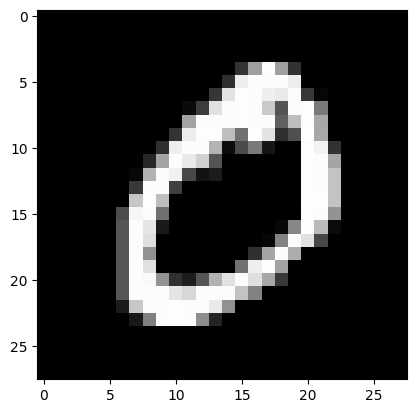

In [2]:
# lOAD DATASET
(X_train, y_train ), (X_test, y_test) = mnist.load_data()
X_train[1].shape
import matplotlib.pyplot as plt

plt.imshow(X_train[1], cmap = 'gray')
plt.show()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

### WITHOUT STRIDE AND PADDING

In [3]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3), padding = 'valid', activation = 'relu', input_shape=(28,28,1)))
model.add(Conv2D(32, kernel_size = (3,3), padding='valid', activation='relu'))
model.add(Conv2D(32, kernel_size = (3,3), padding='valid', activation='relu'))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1790160532.098360      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790160532.101316      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,002,698 (7.64 MB)

 Trainable params: 2,002,698 (7.64 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = keras.callbacks.EarlyStopping(
monitor='val_loss',
min_delta=0.001,
patience=10,
verbose=1,
mode='auto',
restore_best_weights=True
)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history1 = model.fit(X_train,y_train, epochs = 5000,batch_size = 2000, validation_data = (X_test, y_test), verbose=1, callbacks = [early_stop] )

Epoch 1/5000
 3/30 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.3269 - loss: 2.2148

I0000 00:00:1790160543.889967      69 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.8443 - loss: 0.6274 - val_accuracy: 0.9390 - val_loss: 0.2187
Epoch 2/5000
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9541 - loss: 0.1562 - val_accuracy: 0.9726 - val_loss: 0.0911
Epoch 3/5000
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9774 - loss: 0.0790 - val_accuracy: 0.9826 - val_loss: 0.0547
Epoch 4/5000
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9834 - loss: 0.0556 - val_accuracy: 0.9849 - val_loss: 0.0488
Epoch 5/5000
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9878 - loss: 0.0418 - val_accuracy: 0.9877 - val_loss: 0.0405
Epoch 6/5000
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9895 - loss: 0.0344 - val_accuracy: 0.9872 - val_loss: 0.0368
Epoch 7/5000
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9917 - loss: 0.0280 - val_accuracy: 0.9877 - val_loss: 0.0375
Epoch 8/5000
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9927 - loss: 0.0233 - val_accuracy: 0.988

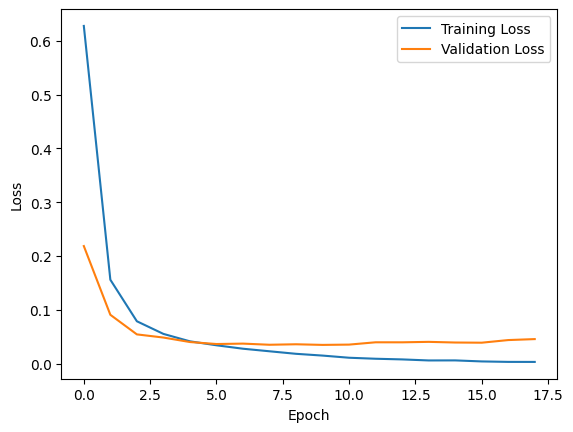

In [8]:
import matplotlib.pyplot as plt

plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

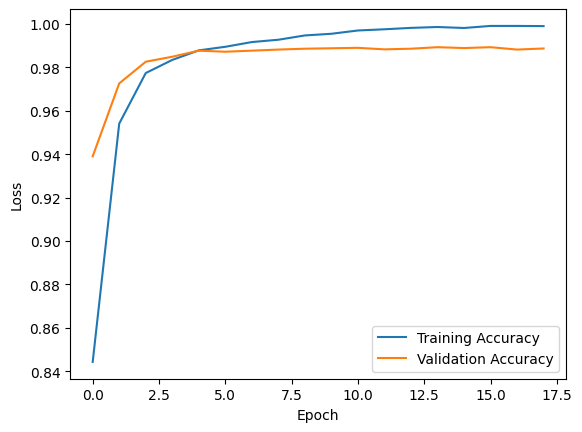

In [9]:
import matplotlib.pyplot as plt

plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### WITH PADDING AND STRIDES

In [10]:
model = Sequential()
model.add(Conv2D(32, kernel_size = (3,3), padding='same', strides=(2,2),activation='relu',input_shape =(28,28,1)))
model.add(Conv2D(32, kernel_size = (3,3), padding ='same',activation='relu', strides = (2,2)))
model.add(Conv2D(32, kernel_size = (32,32), padding='same', activation='relu', strides = (2,2)))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10, activation='relu'))

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 32)       │     1,048,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,125,130 (4.29 MB)

 Trainable params: 1,125,130 (4.29 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = keras.callbacks.EarlyStopping(
monitor='val_loss',
min_delta=0.001,
patience=10,
verbose=1,
mode='auto',
restore_best_weights=True
)

In [13]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [14]:
history2 = model.fit(X_train,y_train , epochs=10000, callbacks=early_stop, batch_size = 2000,validation_data = (X_test, y_test), verbose=1 )

Epoch 1/10000
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.2412 - loss: 3.7082 - val_accuracy: 0.6326 - val_loss: 2.1297
Epoch 2/10000
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2275 - loss: 2.1445 - val_accuracy: 0.0980 - val_loss: 2.3026
Epoch 3/10000
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.0987 - loss: 2.3026 - val_accuracy: 0.0980 - val_loss: 2.3026
Epoch 4/10000
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.0987 - loss: 2.3026 - val_accuracy: 0.0980 - val_loss: 2.3026
Epoch 5/10000
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.0987 - loss: 2.3026 - val_accuracy: 0.0980 - val_loss: 2.3026
Epoch 6/10000
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.0987 - loss: 2.3026 - val_accuracy: 0.0980 - val_loss: 2.3026
Epoch 7/10000
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.0987 - loss: 2.3026 - val_accuracy: 0.0980 - val_loss: 2.3026
Epoch 8/10000
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.0987 - loss: 2.3026 - 

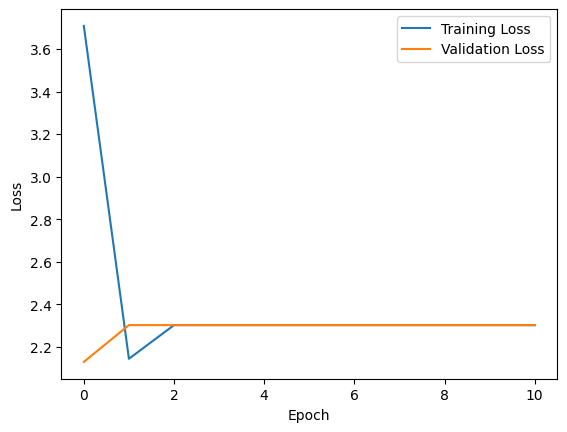

In [15]:
import matplotlib.pyplot as plt

plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

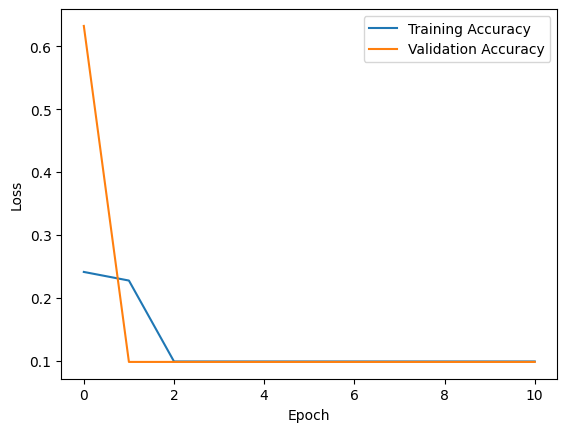

In [16]:
import matplotlib.pyplot as plt

plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()